# 16장 실습 — 이전 절차, sim-to-sim 부터

5부는 지금까지 만든 것을 실기로 넘긴다. 그리고 첫 규칙이 「바로 넘기지 않는다」이다.

실기에 올리는 일은 비싸다. 사람이 붙어야 하고, 물체를 제자리에 돌려놓아야 하고, 하드웨어가 닳고, 가끔 부서진다. 5장에서 본 ASAP의 기록 — 데이터를 모으다 로봇 두 대가 파손됐다는 — 이 그 값의 단위다.

그래서 실기에 올리기 전에 **시뮬 안에서 먼저 무너뜨려 본다.** 이 노트북은 그 절차를 하나씩 세우고, 마지막에 **그 절차가 실기 성적을 예측하는지**까지 잰다. 예측하지 못한다면 절차가 아니라 의식(儀式)일 뿐이다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 손잡이를 다섯 축으로 정리한다

환경은 8장부터 써 온 것이고, 이번에는 교란을 다섯 축으로 나눠 붙인다. 1장에서 나눈 네 갭에 「엔진 자체」를 하나 더한 것이다.

- **엔진** — 적분기와 마찰 원뿔 근사와 솔버 반복 수. 물리는 그대로인데 푸는 방식이 바뀐다
- **구동** — 명령의 양자화와 변화율 제한. 실기 구동기는 실수를 그대로 받지 않는다
- **지연** — 제어 루프의 왕복 시간
- **관측** — 잡음과 교정 편향
- **물리** — 마찰과 게인

앞의 둘이 이 노트북에서 새로 등장한다. 2장에서 마찰 원뿔 근사가 45도에서 √2배를 만든다는 것을 이미 쟀는데, 그때는 물리 이야기였고 여기서는 **이전 검사 항목**이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="{integ}" cone="{cone}"
          iterations="{iters}"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU, KV = .60, 120.
NOMINAL = dict(integ="implicitfast", cone="pyramidal", iters=100)
CACHE = {}


def model_of(mu, kv, integ, cone, iters):
    k = (round(mu, 2), round(kv, 0), integ, cone, iters)
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], kv=k[1], integ=integ, cone=cone,
                       iters=iters))
    return CACHE[k]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .045) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22


class Vec:
    def __init__(self, n, seed=0, mu=MU, kv=KV, lat=0, noise=0.,
                 bias=(0., 0.), quant=0, rate=0., **eng):
        e = dict(NOMINAL, **eng)
        self.m = model_of(mu, kv, e["integ"], e["cone"], e["iters"])
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.lat, self.noise = n, lat, noise
        self.quant, self.rate = quant, rate
        self.bias = np.asarray(bias)
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.buf = [None] * n
        self.prev = np.zeros((n, 2))
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)
        self.prev[i] = 0.

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float) + self.bias
            if self.noise:
                b = b + self.rng.normal(0, self.noise, 2)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def shape(self, i, a):
        # 구동기가 실제로 받는 명령 — 양자화와 변화율 제한
        u = np.clip(a, -1, 1) * AMAX
        if self.quant:
            step = 2 * AMAX / self.quant
            u = np.round(u / step) * step
        if self.rate:
            d = np.clip(u - self.prev[i], -self.rate, self.rate)
            u = self.prev[i] + d
        self.prev[i] = u
        return u

    def step(self, a, keep=None):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            self.buf[i].append(self.shape(i, a[i]))
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3, **kw):
    torch.manual_seed(seed)
    env = Vec(n, seed, **kw)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


class BCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def collect_bc(n_ep=200, seed=1, **kw):
    env = Vec(8, seed, **kw)
    X, Y = [], []
    for _ in range(n_ep * EP // 8):
        o = env.obs()
        acts = []
        for i, d in enumerate(env.d):
            b = np.asarray(d.qpos[0:2], float)
            acts.append(expert(b, np.asarray(d.qpos[7:9], float),
                               env.g[i]) / AMAX)
        acts = np.array(acts, np.float32)
        X.append(o)
        Y.append(acts)
        env.step(acts)
    return np.concatenate(X), np.concatenate(Y)


def train_bc(X, Y, seed=0, epochs=150):
    torch.manual_seed(seed)
    net = BCNet()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def score(pol, n=150, seed=999, **kw):
    kind, net = pol
    torch.manual_seed(seed)
    env = Vec(8, seed, **kw)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            if kind == "rl":
                u = net.dist(o).sample().numpy()
            else:
                u = net(o).numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))

## 넘길 후보를 넷 세운다

이전 절차는 정책 하나를 놓고 「되는가 안 되는가」를 묻는 일이 아니다. 대개 후보가 여럿이고 **그중 무엇을 올릴지 고르는 일**이다. 그래서 후보를 넷 만든다.

- 강화학습 정책 두 개 (씨앗만 다르다)
- 모방학습 정책
- 관측 잡음 3 mm 를 섞어 시연을 모은 모방학습 정책 — 흔히 쓰는 간단한 증강이다

In [5]:
t0 = time.time()
POL = {}
POL["RL 씨앗0"] = ("rl", train_rl(seed=0))
POL["RL 씨앗1"] = ("rl", train_rl(seed=1))
print(f"강화학습 둘 끝  ({time.time()-t0:.0f}s)")
POL["모방"] = ("bc", train_bc(*collect_bc()))
POL["모방+증강"] = ("bc", train_bc(*collect_bc(noise=.003)))
print(f"모방 둘 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("정책", 18) + pad("학습 조건 성공률", 18, True))
for k, p in POL.items():
    print(pad(k, 18) + pad(f"{score(p):.2f}", 18, True))

강화학습 둘 끝  (96s)


모방 둘 끝  (122s)

정책                학습 조건 성공률


RL 씨앗0                        0.89


RL 씨앗1                        0.97


모방                            0.91


모방+증강                       0.92


## 단계를 하나씩 올린다

이제 축마다 따로 흔든다. **한 번에 하나씩**이 요점이다. 전부 한꺼번에 켜 놓고 「실기에서 안 된다」고 하면 어디를 고칠지 알 수 없다.

각 단계의 크기는 실기에서 예상되는 값의 언저리로 잡는다. 이 값들을 어디서 얻는가가 4장의 일이었다.

그리고 한 가지를 지킨다. **마지막에 「실기」라고 부를 조건은 아홉 단계를 그대로 합친 것**이어야 한다. 단계별 시험을 실기보다 세게 걸어 놓으면 그 시험은 실기를 예측할 수 없고, 약하게 걸어 놓으면 통과했는데 실기에서 무너진다. 아래 코드가 `REAL` 을 `STAGES` 에서 기계적으로 만드는 이유다.

In [6]:
STAGES = {
    "① 엔진 — 적분기": dict(integ="Euler"),
    "② 엔진 — 마찰 원뿔": dict(cone="elliptic"),
    "③ 엔진 — 솔버 반복": dict(iters=10),
    "④ 구동 — 양자화": dict(quant=16),
    "⑤ 구동 — 변화율 제한": dict(rate=.12),
    "⑥ 지연 1스텝": dict(lat=1),
    "⑦ 관측 잡음 6mm": dict(noise=.006),
    "⑧ 관측 편향 6mm": dict(bias=(.006, -.004)),
    "⑨ 물리 — 마찰 0.8": dict(mu=.80),
}
REAL = {}
for _kw in STAGES.values():     # 실기 = 아홉 단계를 한꺼번에 켠 것
    REAL.update(_kw)

t0 = time.time()
tab = {k: {} for k in POL}
for name, p in POL.items():
    for st, kw in STAGES.items():
        tab[name][st] = score(p, **kw)
    tab[name]["실기 (전부 한꺼번에)"] = score(p, **REAL)
    print(f"{name} 끝  ({time.time()-t0:.0f}s)")

print()
hdr = list(POL)
print(pad("단계", 22) + "".join(pad(h, 13, True) for h in hdr))
for st in list(STAGES) + ["실기 (전부 한꺼번에)"]:
    print(pad(st, 22)
          + "".join(pad(f"{tab[h][st]:.2f}", 13, True)
                      for h in hdr))

RL 씨앗0 끝  (22s)


RL 씨앗1 끝  (44s)


모방 끝  (67s)


모방+증강 끝  (89s)

단계                       RL 씨앗0     RL 씨앗1         모방    모방+증강
① 엔진 — 적분기                0.91         0.96         0.99         0.94
② 엔진 — 마찰 원뿔             0.97         0.93         0.94         0.27
③ 엔진 — 솔버 반복             0.89         0.97         0.91         0.92
④ 구동 — 양자화                0.91         0.93         0.94         0.81
⑤ 구동 — 변화율 제한           0.71         0.43         0.65         0.00
⑥ 지연 1스텝                   0.50         0.65         0.85         0.46
⑦ 관측 잡음 6mm                0.88         0.91         0.99         0.86
⑧ 관측 편향 6mm                0.97         0.95         0.11         0.39
⑨ 물리 — 마찰 0.8              0.94         0.93         0.88         0.53
실기 (전부 한꺼번에)           0.39         0.11         0.75         0.09


## 단계별 점수로 마지막 줄을 맞힐 수 있는가

이전 절차가 의식이 아니라 도구이려면, 이 표의 앞 아홉 줄로 마지막 줄을 짐작할 수 있어야 한다. 세 가지 방법을 시험한다 — 학습 조건 점수, 아홉 단계의 평균, 그리고 **가장 낮은 단계 점수**다. 마지막 것이 가장 그럴듯하다. 사슬은 가장 약한 고리에서 끊어지니까.

In [7]:
def mmrv(pred, real):
    pred, real = np.asarray(pred), np.asarray(real)
    out = []
    for i in range(len(pred)):
        v = [abs(real[i] - real[j])
             for j in range(len(pred))
             if (pred[i] - pred[j]) * (real[i] - real[j]) < 0]
        out.append(max(v) if v else 0.)
    return float(np.mean(out))


rea = [tab[h]["실기 (전부 한꺼번에)"] for h in hdr]
weak = [min(tab[h][s] for s in STAGES) for h in hdr]
mean = [np.mean([tab[h][s] for s in STAGES]) for h in hdr]
nom = [score(POL[h]) for h in hdr]

print(pad("예측에 쓴 값", 20) + pad("MMRV ↓", 12, True)
      + pad("Pearson r ↑", 14, True))
for nm, v in (("학습 조건 점수", nom), ("아홉 단계의 평균", mean),
              ("가장 약한 단계", weak)):
    r = float(np.corrcoef(v, rea)[0, 1])
    print(pad(nm, 20) + pad(f"{mmrv(v, rea):.3f}", 12, True)
          + pad(f"{r:.3f}", 14, True))

print()
print(pad("정책", 18) + pad("가장 약한 단계", 18, True)
      + pad("그 점수", 12, True) + pad("실기", 10, True))
for h in hdr:
    s = min(STAGES, key=lambda s: tab[h][s])
    print(pad(h, 18) + pad(s, 18, True)
          + pad(f"{tab[h][s]:.2f}", 12, True)
          + pad(f"{tab[h]['실기 (전부 한꺼번에)']:.2f}", 10, True))

예측에 쓴 값              MMRV ↓   Pearson r ↑
학습 조건 점수             0.560        -0.571
아홉 단계의 평균           0.410         0.388
가장 약한 단계             0.410        -0.111

정책                  가장 약한 단계     그 점수      실기
RL 씨앗0                ⑥ 지연 1스텝        0.50      0.39
RL 씨앗1          ⑤ 구동 — 변화율 제한        0.43      0.11
모방                 ⑧ 관측 편향 6mm        0.11      0.75
모방+증강         ⑤ 구동 — 변화율 제한        0.00      0.09


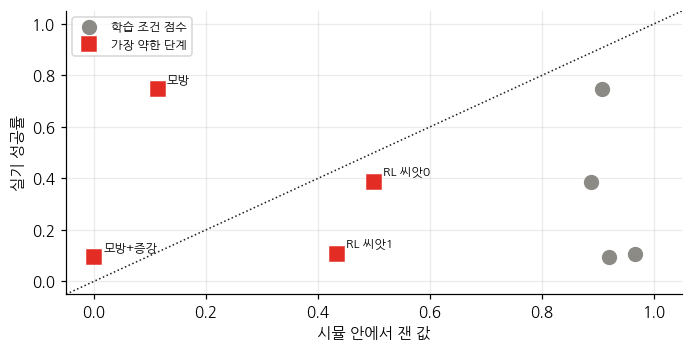

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.plot(nom, rea, "o", color=GREY, ms=9, label="학습 조건 점수")
ax.plot(weak, rea, "s", color=RED, ms=9, label="가장 약한 단계")
for x, y, h in zip(weak, rea, hdr):
    ax.annotate(h, (x, y), fontsize=8, xytext=(6, 4),
                textcoords="offset points")
lim = [-.05, 1.05]
ax.plot(lim, lim, ":", color=INK, lw=1)
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_xlabel("시뮬 안에서 잰 값")
ax.set_ylabel("실기 성공률")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 교란은 서로를 상쇄한다

이 역전이 어디서 오는지 찾아본다. 관측 편향을 켜 둔 채로 나머지 축을 하나씩 더해 본다.

In [9]:
base_bias = score(POL["모방"], **STAGES["⑧ 관측 편향 6mm"])
print(f"모방 정책, 관측 편향만: {base_bias:.2f}")
print()
print(pad("편향에 무엇을 더했나", 26) + pad("성공률", 10, True)
      + pad("변화", 10, True))
for st, kw in STAGES.items():
    if st.startswith("⑧"):
        continue
    v = score(POL["모방"], **dict(STAGES["⑧ 관측 편향 6mm"], **kw))
    print(pad(st, 26) + pad(f"{v:.2f}", 10, True)
          + pad(f"{v-base_bias:+.2f}", 10, True))

모방 정책, 관측 편향만: 0.11

편향에 무엇을 더했나          성공률      변화


① 엔진 — 적분기                 0.30     +0.19


② 엔진 — 마찰 원뿔              0.05     -0.07


③ 엔진 — 솔버 반복              0.11     +0.00


④ 구동 — 양자화                 0.33     +0.22


⑤ 구동 — 변화율 제한            0.01     -0.11


⑥ 지연 1스텝                    0.79     +0.68


⑦ 관측 잡음 6mm                 0.94     +0.83


⑨ 물리 — 마찰 0.8               0.03     -0.08


## 정리

**실기에 올리기 전에 시뮬 안에서 먼저 무너뜨린다.** 아홉 단계를 다 재는 데 실기 에피소드가 한 판도 들지 않았다.

**한 번에 한 축씩 흔든다.** 전부 켜 놓고 재면 점수 하나가 나오고, 그 점수로는 어디를 고칠지 알 수 없다.

**엔진 축은 이 과제에서 쌌다.** 적분기·마찰 원뿔·솔버 반복을 바꿔도 크게 흔들리지 않았다. 대신 구동·지연·관측 축이 비쌌다. 어느 축이 비싼지는 과제마다 다르고, 그것을 아는 것 자체가 이전 절차의 산출물이다.

**단계별 점수로 합쳐진 결과를 예측할 수는 없다.** 학습 조건 점수도, 평균도, 최솟값도 맞히지 못했다. 교란끼리 상쇄하기 때문이다 — 관측 편향으로 지나치던 정책을 높은 마찰이 구해 주는 식이다.

**상호작용의 크기가 단일 축의 효과만큼 크다.** 모방 정책에 관측 잡음을 더했더니 편향만 걸었을 때의 0.11이 0.94가 됐다. 이런 항이 있는 한 축별 점수를 모아 합을 계산하는 방식은 성립하지 않는다.

**그래서 단계별 시험은 진단으로 쓰고, 예측은 합친 조건에서 직접 잰다.** 둘 다 시뮬 안의 일이라 실기 예산은 여전히 0이다.

다음 장은 이 표가 「나빴다」고 말한 뒤의 이야기다. 무너진 정책을 어떻게 읽을 것인가.